In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [4]:
import pandas as pd
import numpy as np

# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Sort values
nav = nav.sort_values(['amfi_code', 'date'])

# Daily Return
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Check result
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
annual_returns = nav.groupby('amfi_code')['daily_return'].apply(
    lambda x: ((1 + x.dropna()).prod() ** (252 / len(x.dropna()))) - 1
)

annual_returns = annual_returns.reset_index()
annual_returns.columns = ['amfi_code', 'annualized_return']

annual_returns.head()

,amfi_code,annualized_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [6]:
annual_returns.to_csv(
    "../reports/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully")

returns_computed.csv saved successfully


In [7]:
scheme = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print(scheme.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [8]:
scheme = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [9]:
scheme.shape

(40, 19)

In [10]:
scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [11]:
scheme.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [13]:
# Ranking

scheme['return_rank'] = scheme['return_3yr_pct'].rank(ascending=False)

scheme['sharpe_rank'] = scheme['sharpe_ratio'].rank(ascending=False)

scheme['alpha_rank'] = scheme['alpha'].rank(ascending=False)

scheme['expense_rank'] = scheme['expense_ratio_pct'].rank(ascending=True)

scheme['drawdown_rank'] = scheme['max_drawdown_pct'].rank(ascending=False)

# Composite Score

scheme['fund_score'] = (
    0.30 * scheme['return_rank'] +
    0.25 * scheme['sharpe_rank'] +
    0.20 * scheme['alpha_rank'] +
    0.15 * scheme['expense_rank'] +
    0.10 * scheme['drawdown_rank']
)

scheme[['scheme_name','fund_score']].head()

,scheme_name,fund_score
0,SBI Bluechip Fund - Regular Plan - Growth,27.550
1,SBI Bluechip Fund - Direct Plan - Growth,24.375
2,SBI Small Cap Fund - Regular Plan - Growth,12.750
3,SBI Small Cap Fund - Direct Plan - Growth,13.800
4,SBI Magnum Gilt Fund - Regular Plan - Growth,16.800


In [14]:
scorecard = scheme.sort_values(
    'fund_score',
    ascending=True
)

scorecard[['scheme_name','fund_score']].head(10)

,scheme_name,fund_score
22,Kotak Flexicap Fund - Regular - Growth,12.300
2,SBI Small Cap Fund - Regular Plan - Growth,12.750
14,ICICI Pru Liquid Fund - Regular - Growth,12.800
9,HDFC Short Term Debt Fund - Regular - Growth,12.900
21,Kotak Emerging Equity Fund - Regular - Growth,13.700
3,SBI Small Cap Fund - Direct Plan - Growth,13.800
34,Mirae Asset Large Cap Fund - Regular - Growth,14.325
29,ABSL Small Cap Fund - Regular - Growth,15.000
23,Kotak Liquid Fund - Regular - Growth,15.350
33,UTI Flexi Cap Fund - Regular - Growth,15.875


In [15]:
scorecard = scheme.sort_values(
    'fund_score',
    ascending=True
)

scorecard[['scheme_name', 'fund_score']].head(10)

,scheme_name,fund_score
22,Kotak Flexicap Fund - Regular - Growth,12.300
2,SBI Small Cap Fund - Regular Plan - Growth,12.750
14,ICICI Pru Liquid Fund - Regular - Growth,12.800
9,HDFC Short Term Debt Fund - Regular - Growth,12.900
21,Kotak Emerging Equity Fund - Regular - Growth,13.700
3,SBI Small Cap Fund - Direct Plan - Growth,13.800
34,Mirae Asset Large Cap Fund - Regular - Growth,14.325
29,ABSL Small Cap Fund - Regular - Growth,15.000
23,Kotak Liquid Fund - Regular - Growth,15.350
33,UTI Flexi Cap Fund - Regular - Growth,15.875


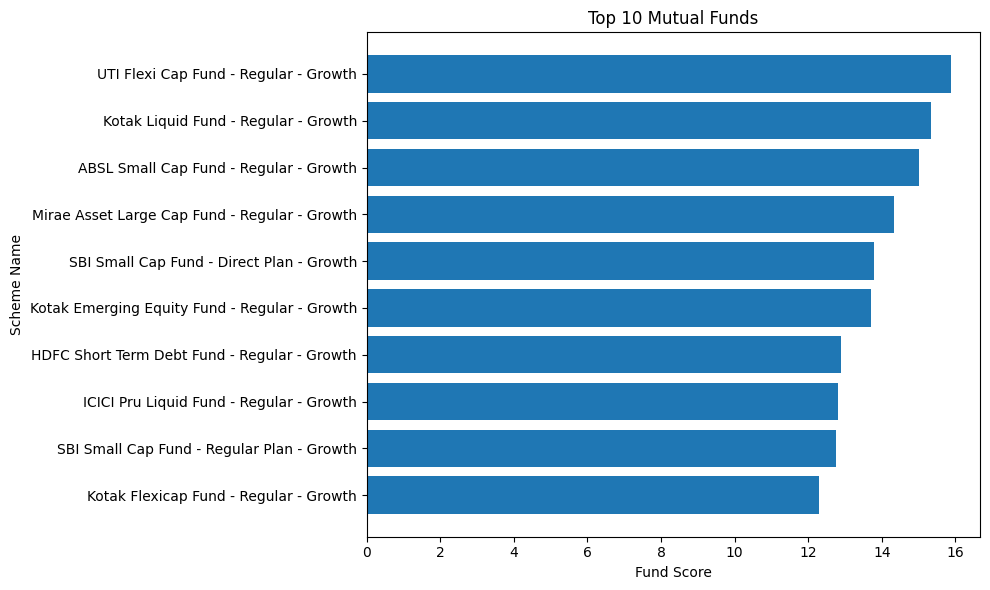

In [16]:
import matplotlib.pyplot as plt

top10 = scorecard.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['scheme_name'], top10['fund_score'])

plt.title("Top 10 Mutual Funds")
plt.xlabel("Fund Score")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

In [17]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.columns)

Index(['date', 'index_name', 'close_value'], dtype='str')


In [18]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [19]:
print(benchmark['index_name'].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [20]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

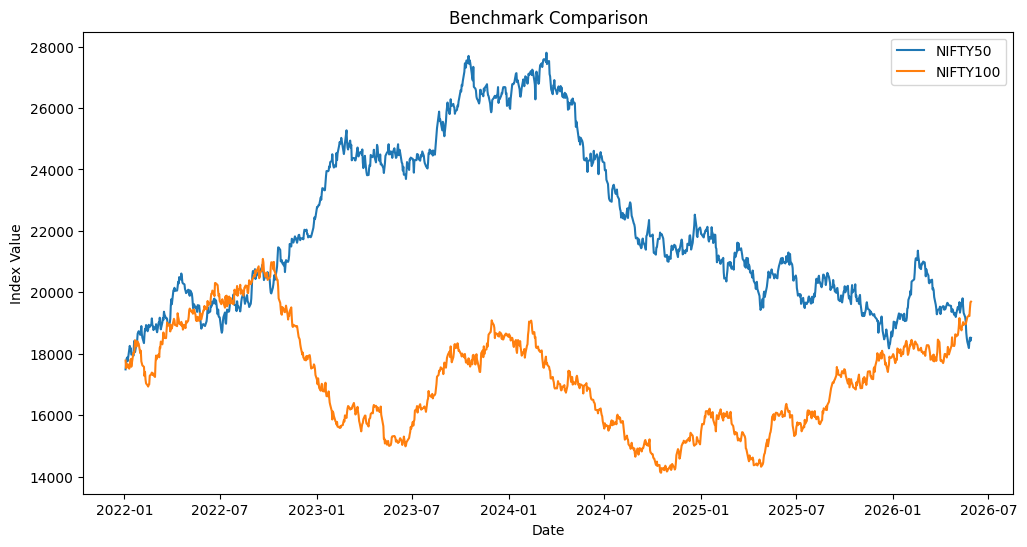

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    label='NIFTY50'
)

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    label='NIFTY100'
)

plt.title("Benchmark Comparison")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()

plt.show()

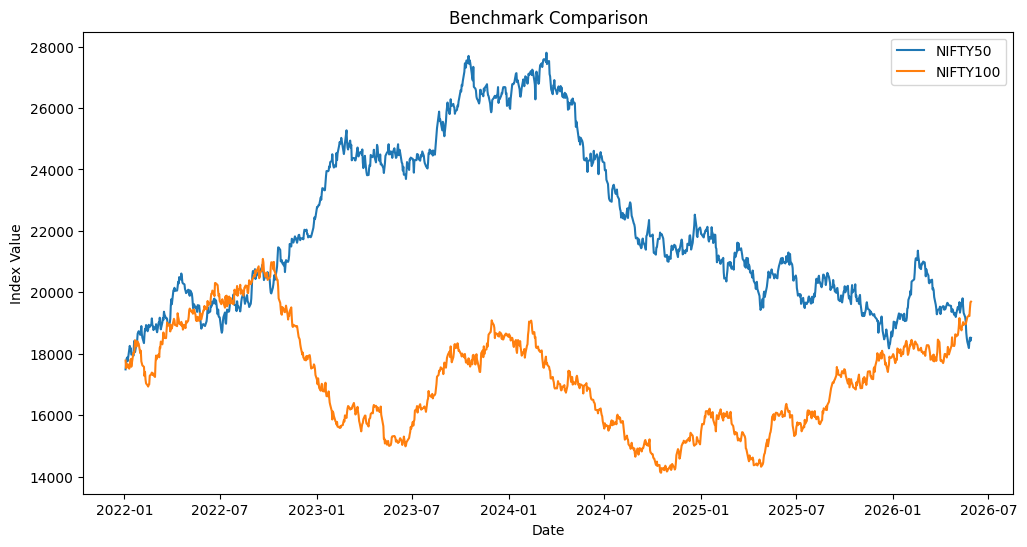

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    label='NIFTY50'
)

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    label='NIFTY100'
)

plt.title("Benchmark Comparison")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

Observation:
NIFTY50 and NIFTY100 exhibit similar long-term market trends, though their performance levels and volatility differ over time.

In [23]:
scheme.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'return_rank', 'sharpe_rank',
       'alpha_rank', 'expense_rank', 'drawdown_rank', 'fund_score'],
      dtype='str')

In [24]:
scheme.to_csv("../reports/fund_scorecard.csv", index=False)

print("Fund Scorecard Saved Successfully")

Fund Scorecard Saved Successfully


In [25]:
scheme[['scheme_name','fund_score']].sort_values(
    by='fund_score',
    ascending=False
).head(10)

,scheme_name,fund_score
36,Mirae Asset Tax Saver Fund - Regular - Growth,32.400
10,ICICI Pru Bluechip Fund - Regular - Growth,31.775
24,Axis Bluechip Fund - Regular - Growth,29.875
0,SBI Bluechip Fund - Regular Plan - Growth,27.550
31,UTI Nifty 50 Index Fund - Regular - Growth,27.175
20,Kotak Bluechip Fund - Regular - Growth,26.500
17,Nippon India Small Cap Fund - Regular - Growth,25.050
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,24.625
1,SBI Bluechip Fund - Direct Plan - Growth,24.375
39,DSP Small Cap Fund - Regular - Growth,24.000


# Day 4 Conclusion

1. Computed fund return metrics from NAV history.
2. Analyzed benchmark indices including NIFTY50.
3. Built a fund scorecard using return, Sharpe ratio, Alpha, expense ratio and drawdown metrics.
4. Ranked mutual funds based on composite fund score.
5. Identified top-performing and lower-performing funds.
6. Generated benchmark comparison visualization.

In [26]:
scheme[['scheme_name','fund_score']]\
.sort_values('fund_score', ascending=False)\
.head(5)

,scheme_name,fund_score
36,Mirae Asset Tax Saver Fund - Regular - Growth,32.400
10,ICICI Pru Bluechip Fund - Regular - Growth,31.775
24,Axis Bluechip Fund - Regular - Growth,29.875
0,SBI Bluechip Fund - Regular Plan - Growth,27.550
31,UTI Nifty 50 Index Fund - Regular - Growth,27.175


In [27]:
scheme[[
    'scheme_name',
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'sharpe_ratio',
    'sortino_ratio',
    'alpha',
    'beta',
    'max_drawdown_pct',
    'fund_score'
]].head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown_pct,fund_score
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45,0.88,1.29,0.87,0.89,-21.70,27.550
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23,0.81,1.29,1.78,0.87,-24.43,24.375
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67,0.94,1.35,1.23,0.89,-13.35,12.750
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82,0.93,1.67,1.13,1.04,-24.78,13.800
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43,1.52,2.11,1.60,0.22,-2.30,16.800
